In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

# Load and prepare data
df = pd.read_csv('../data/Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (6435, 12)


In [3]:
# Sort data properly first
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Lag features — previous weeks sales as predictor
df['Sales_Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)  # last week
df['Sales_Lag_2'] = df.groupby('Store')['Weekly_Sales'].shift(2)  # 2 weeks ago
df['Sales_Lag_4'] = df.groupby('Store')['Weekly_Sales'].shift(4)  # 4 weeks ago

# Rolling average — smooth out noise
df['Sales_Rolling_4'] = df.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(window=4).mean()
)

# Drop rows with NaN created by lag features
df = df.dropna()

print("Shape after feature engineering:", df.shape)
print("\nNew features added:")
df[['Store', 'Date', 'Weekly_Sales', 'Sales_Lag_1', 'Sales_Lag_2', 
    'Sales_Lag_4', 'Sales_Rolling_4']].head(10)

Shape after feature engineering: (6255, 16)

New features added:


,Store,Date,Weekly_Sales,Sales_Lag_1,Sales_Lag_2,Sales_Lag_4,Sales_Rolling_4
4,1,2010-03-05,1554806.68,1409727.59,1611968.17,1643690.90,1.576836e+06
5,1,2010-03-12,1439541.59,1554806.68,1409727.59,1641957.44,1.554615e+06
6,1,2010-03-19,1472515.79,1439541.59,1554806.68,1611968.17,1.504011e+06
7,1,2010-03-26,1404429.92,1472515.79,1439541.59,1409727.59,1.469148e+06
8,1,2010-04-02,1594968.28,1404429.92,1472515.79,1554806.68,1.467823e+06
9,1,2010-04-09,1545418.53,1594968.28,1404429.92,1439541.59,1.477864e+06
10,1,2010-04-16,1466058.28,1545418.53,1594968.28,1472515.79,1.504333e+06
11,1,2010-04-23,1391256.12,1466058.28,1545418.53,1404429.92,1.502719e+06
12,1,2010-04-30,1425100.71,1391256.12,1466058.28,1594968.28,1.499425e+06
13,1,2010-05-07,1603955.12,1425100.71,1391256.12,1545418.53,1.456958e+06


In [4]:
# Select features for model
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 
            'CPI', 'Unemployment', 'Year', 'Month', 'Week', 
            'Quarter', 'Sales_Lag_1', 'Sales_Lag_2', 
            'Sales_Lag_4', 'Sales_Rolling_4']

target = 'Weekly_Sales'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:", features)

Features shape: (6255, 14)
Target shape: (6255,)

Features used: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter', 'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_4', 'Sales_Rolling_4']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # for reproducibility
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5004
Testing samples: 1251


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train model
rf_model = RandomForestRegressor(
    n_estimators=100,    # 100 decision trees
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"MAE:  ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

Random Forest Results:
MAE:  $51,106.70
RMSE: $78,561.57
R²:   0.9816


In [7]:
from xgboost import XGBRegressor

# Train model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Predict
xgb_predictions = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Results:")
print(f"MAE:  ${xgb_mae:,.2f}")
print(f"RMSE: ${xgb_rmse:,.2f}")
print(f"R²:   {xgb_r2:.4f}")

XGBoost Results:
MAE:  $42,840.55
RMSE: $69,415.98
R²:   0.9857


Model Comparison:
        Model          MAE         RMSE  R² Score
Random Forest 51106.698368 78561.568714  0.981622
      XGBoost 42840.546865 69415.982706  0.985652


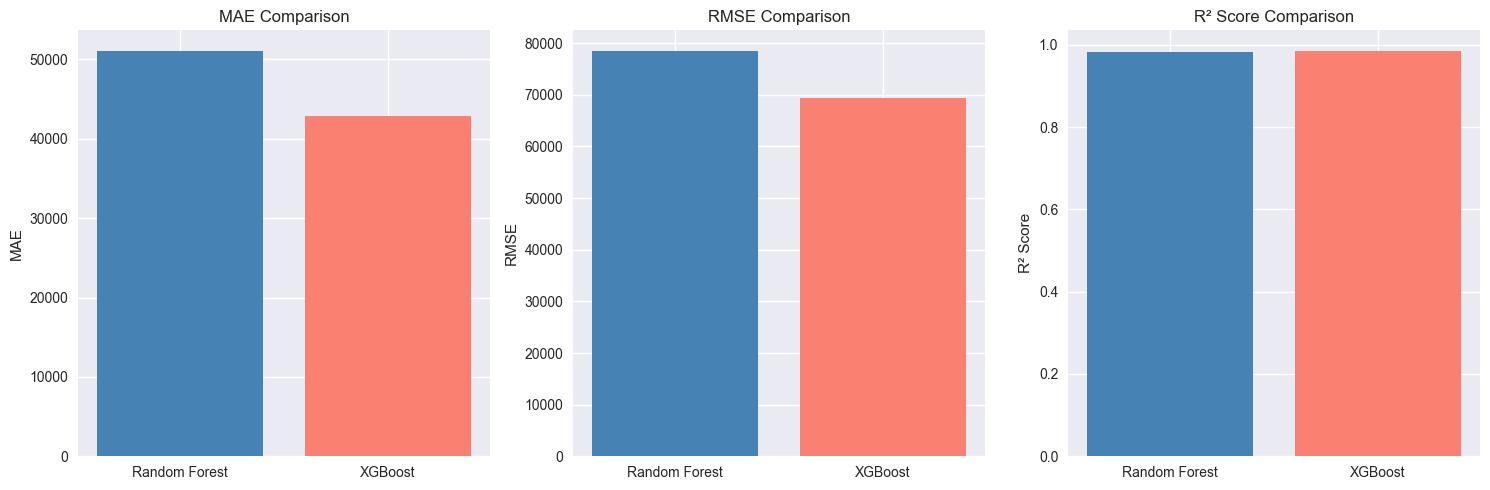

In [8]:
# Comparison table
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [rf_mae, xgb_mae],
    'RMSE': [rf_rmse, xgb_rmse],
    'R² Score': [rf_r2, xgb_r2]
})

print("Model Comparison:")
print(results.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R² Score']
colors = ['steelblue', 'salmon']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.savefig('../outputs/graphs/07_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\sahoo\AppData\Local\Temp\ipykernel_28716\97111380.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_d')


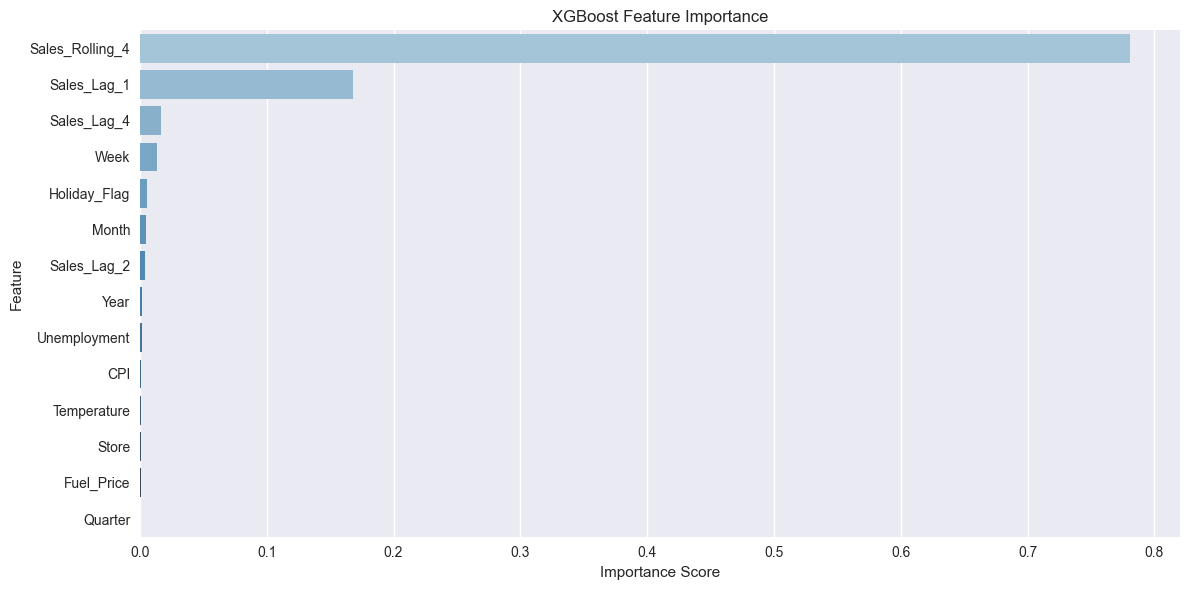


Top 5 most important features:
            Feature  Importance
13  Sales_Rolling_4    0.781164
10      Sales_Lag_1    0.168020
12      Sales_Lag_4    0.016719
8              Week    0.013461
1      Holiday_Flag    0.005421


In [9]:
# XGBoost feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_d')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../outputs/graphs/08_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head())

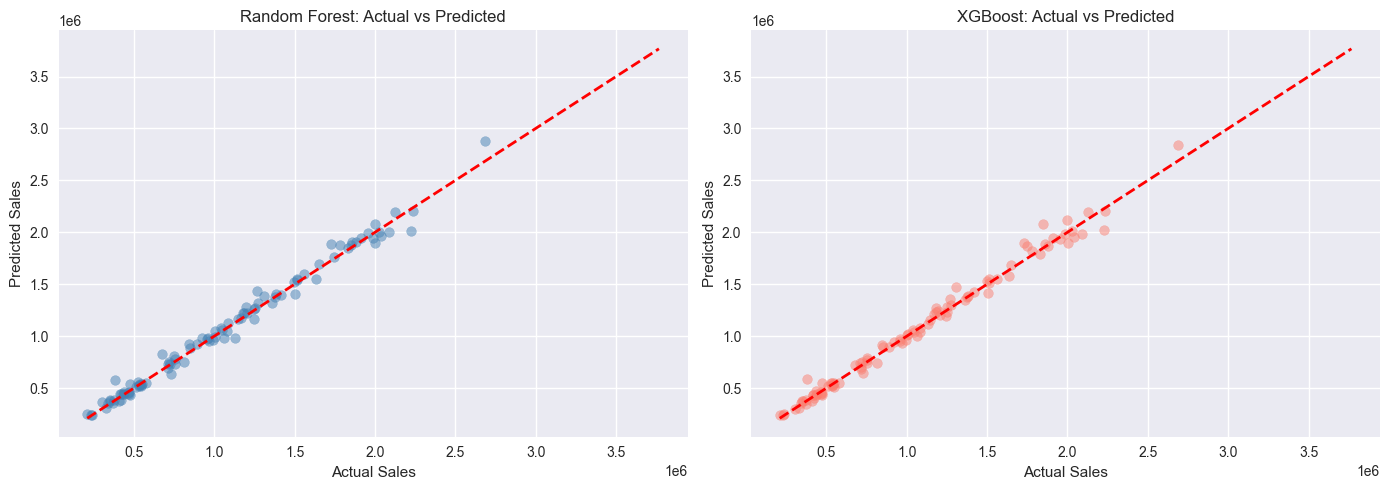

In [10]:
# Sample 100 points for clean visualization
sample_idx = np.random.choice(len(y_test), 100, replace=False)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test.iloc[sample_idx], 
            rf_predictions[sample_idx], 
            alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.subplot(1, 2, 2)
plt.scatter(y_test.iloc[sample_idx], 
            xgb_predictions[sample_idx], 
            alpha=0.5, color='salmon')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.tight_layout()
plt.savefig('../outputs/graphs/09_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save both models
joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')

print("Models saved successfully!")
print("Files saved:")
print("  → models/random_forest_model.pkl")
print("  → models/xgboost_model.pkl")

Models saved successfully!
Files saved:
  → models/random_forest_model.pkl
  → models/xgboost_model.pkl
